<a href="https://colab.research.google.com/github/priyakutty7598/Mini-project-1/blob/main/MINI_PROJECT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/ONINE_FOOD_DELIVERY_ANALYSIS.csv')
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,NaN,NaN,Mumbai,NaN,RES295,Restaurant_500,Arabian,6/10/2024,...,132.0,Card,Delivered,NaN,DP835,2.0,4.0,Weekday,True,0.17
99996,ORD099997,CUST6158,NaN,Male,Mumbai,East,RES157,Restaurant_458,Arabian,4/22/2024,...,1078.0,NaN,Delivered,NaN,DP476,4.0,3.5,Weekday,False,-0.15
99997,ORD099998,CUST2155,NaN,NaN,Delhi,East,RES287,Restaurant_273,NaN,2/23/2024,...,NaN,COD,Cancelled,NaN,DP577,2.0,4.0,Weekday,True,0.47
99998,ORD099999,CUST3015,NaN,Female,Delhi,North,RES491,Restaurant_241,NaN,12/10/2024,...,NaN,NaN,Delivered,NaN,DP896,NaN,4.3,Weekday,NaN,0.44


In [ ]:
df['Order_Value']

,Order_Value
0,NaN
1,4869.0
2,757.0
3,NaN
4,372.0
...,...
99995,232.0
99996,1098.0
99997,NaN
99998,NaN


In [ ]:
df.shape

(100000, 25)

In [ ]:
df.size

2500000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   object 
 4   City                 83274 non-null   object 
 5   Area                 83315 non-null   object 
 6   Restaurant_ID        100000 non-null  object 
 7   Restaurant_Name      100000 non-null  object 
 8   Cuisine_Type         83115 non-null   object 
 9   Order_Date           98986 non-null   object 
 10  Order_Time           98002 non-null   object 
 11  Delivery_Time_Min    66641 non-null   float64
 12  Distance_km          66530 non-null   float64
 13  Order_Value          66673 non-null   float64
 14  Discount_Applied     83285 non-null   float64
 15  Final_Amount      

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Age,50093
Customer_Gender,24856
City,16726
Area,16685
Restaurant_ID,0
Restaurant_Name,0
Cuisine_Type,16885
Order_Date,1014


IMPUTATION TECHNIQUE


In [ ]:
import pandas as ps
from sklearn.impute import SimpleImputer

In [ ]:
num_column = df.select_dtypes(include = ['float']).columns
categorical_column = df.select_dtypes(include = ['object']).columns
numerical_imputer = SimpleImputer(strategy = 'median')
df[num_column] = numerical_imputer.fit_transform(df[num_column])
categorical_imputer = SimpleImputer(strategy = 'most_frequent')
df[categorical_column] = categorical_imputer.fit_transform(df[categorical_column])

In [ ]:
df['Customer_Age'] = df['Customer_Age'].astype(int)
df['Delivery_Rating'] = df['Delivery_Rating'].astype(int)
df['Delivery_Time_Min'] = df['Delivery_Time_Min'].astype(int)
df['Distance_km'] = df['Distance_km'].astype(int)

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'],format = 'mixed')
df['Order_Time'] = pd.to_datetime(df['Order_Time'])

**Removing or capping outliers (delivery time, order value)

In [ ]:
Q1 = df['Delivery_Time_Min'].quantile(0.25)
Q3 = df['Delivery_Time_Min'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers_count = ((df[['Delivery_Time_Min','Order_Value']] < lower_bound) | (df[['Delivery_Time_Min','Order_Value']]> upper_bound)).sum()
print(f" Outliers identified : {outliers_count}")

 Outliers identified : Delivery_Time_Min        0
Order_Value          94391
dtype: int64


Correcting invalid values (ratings > 5, negative profit margin)

In [ ]:
group_by = df.groupby('Delivery_Rating')
count = group_by['Delivery_Rating'].count()
print(count)
group_by = df.groupby('Restaurant_Rating')
count = group_by['Restaurant_Rating'].count()
print(count)


Delivery_Rating
1    16818
2    16896
3    32931
4    16885
5    16470
Name: Delivery_Rating, dtype: int64
Restaurant_Rating
3.0    2002
3.1    4047
3.2    3985
3.3    3904
3.4    4005
3.5    3969
3.6    4085
3.7    3980
3.8    4080
3.9    3966
4.0    3975
4.1    3984
4.2    4032
4.3    4041
4.4    4088
4.5    3955
4.6    3917
4.7    4035
4.8    3927
4.9    3980
5.0    4024
5.1    4031
5.2    4054
5.3    4016
5.4    3876
5.5    2042
Name: Restaurant_Rating, dtype: int64


In [ ]:
df['Profit_Margin'] =  df['Profit_Margin'].abs()

In [ ]:
group_by = df.groupby('Profit_Margin')
count = group_by['Profit_Margin'].count()
print(count)

Profit_Margin
0.00    1506
0.01    2929
0.02    2749
0.03    2893
0.04    2824
0.05    2809
0.06    2811
0.07    2842
0.08    2797
0.09    2850
0.10    2849
0.11    2905
0.12    2780
0.13    2812
0.14    2891
0.15    2862
0.16    2818
0.17    2827
0.18    2816
0.19    2909
0.20    2173
0.21    1459
0.22    1388
0.23    1441
0.24    1439
0.25    1502
0.26    1513
0.27    1461
0.28    1396
0.29    1426
0.30    1469
0.31    1466
0.32    1501
0.33    1449
0.34    1474
0.35    1387
0.36    1446
0.37    1425
0.38    1433
0.39    1417
0.40    1414
0.41    1362
0.42    1438
0.43    1394
0.44    1406
0.45    1456
0.46    1403
0.47    1415
0.48    1334
0.49    1474
0.50     760
Name: Profit_Margin, dtype: int64


Standardizing categorical values

In [ ]:
categorical_column = ['Customer_Gender','City','Area','Restaurant_ID', 'Restaurant_Name','Cuisine_Type', 'Payment_Mode', 'Cancellation_Reason','Order_Day','Order_Status']
for col in categorical_column:
    df[col] = df[col].str.lower()
    df[col] = df[col].str.strip()

Ensuring logical consistency (e.g., cancelled orders vs ratings)

In [ ]:
df[(df['Order_Status'] == 'Cancelled') & (df['Delivery_Rating'] > 0)]

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin


In [ ]:
import numpy as np

EDA & Analytics

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Distribution of order values and delivery time

In [ ]:
from scipy.stats import skew,kurtosis
skewness = skew(df[['Delivery_Time_Min','Order_Value']]) # both are positive skewness
print(skewness)

[0.60081415 0.971635  ]


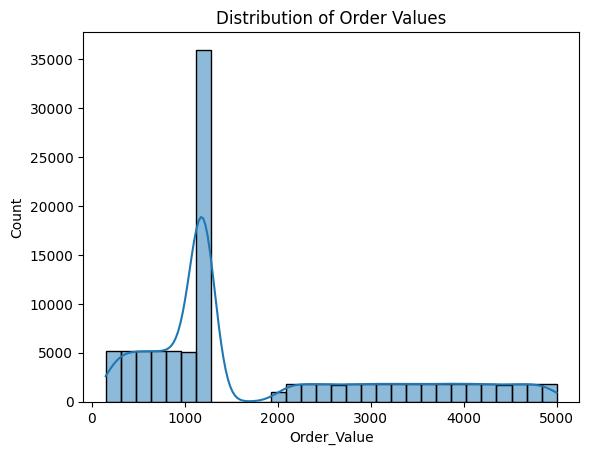

In [ ]:
sns.histplot(df['Order_Value'], bins=30, kde=True)
plt.title("Distribution of Order Values")
plt.show()

INSIGHT:

The order value shows a right-skewed distribution.

This indicating most customer place small value orders, while a few high value order exist.

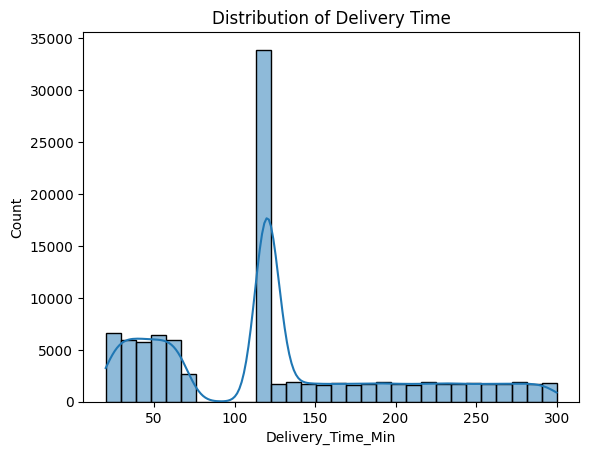

In [ ]:
# Distribution of Delivery Time
sns.histplot(df['Delivery_Time_Min'], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

INSIGHTS:

The delivery time minutes shows a right-skewed distrbution.

Most deliveries are completed within a specific time range indicating occasional delayed deliveries.

 A few extreme delivery times may indicate traffic delays.

City-wise and cuisine-wise order analysis

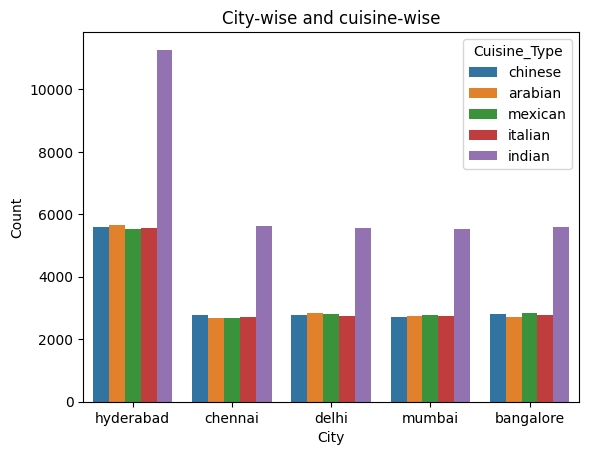

In [ ]:
sns.countplot(x='City',hue = 'Cuisine_Type',data=df)
plt.xlabel('City')
plt.ylabel('Count')
plt.title('City-wise and cuisine-wise')
plt.show()

INSIGHTS:

The Indian cuisine dominate every city

Chinese, Arabian,Mexican,Italian show nearly identical demand

Hydrabed is the highest volume market in Indian and other city shown identical patterns

Weekend vs weekday demand


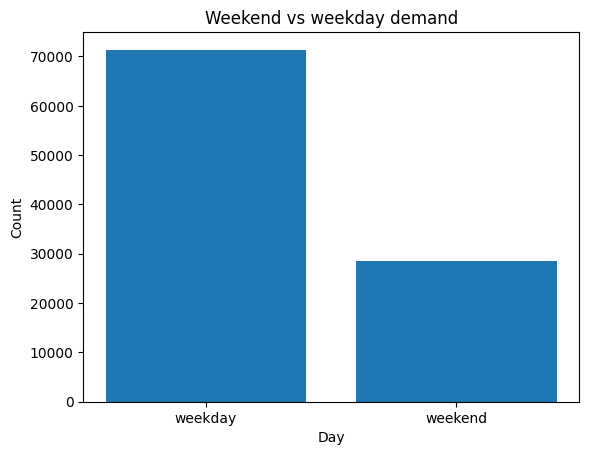

In [ ]:
import matplotlib.pyplot as plt
x=df['Order_Day'].value_counts()
plt.bar(x.index, x.values)
plt.xlabel("Day")
plt.ylabel("Count")
plt.title("Weekend vs weekday demand")
plt.show()

INSIGHTS:

The weekday orders are higher than weekend

Demand driven by college, offices, orders





**Distance vs delivery delay relationship**

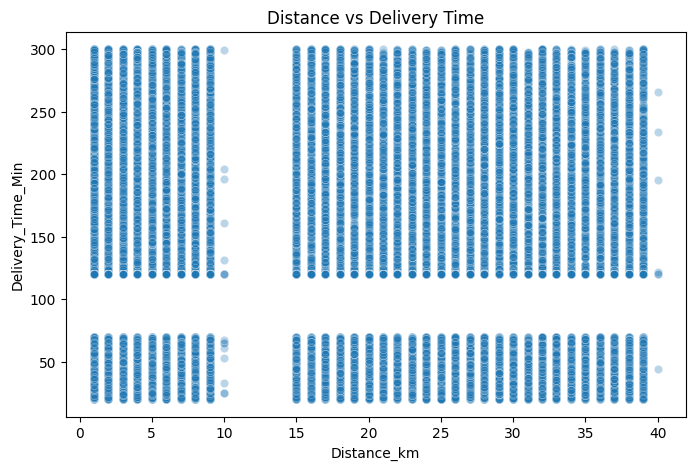

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Distance_km', y='Delivery_Time_Min', data=df, alpha=0.3)
plt.title("Distance vs Delivery Time")
plt.show()

INSIGHTS

The scatter plot shows a positive relationship between delivery distance and delivery time.

As the distance increases, delivery times generally increase.

**Cancellation reasons analysis**

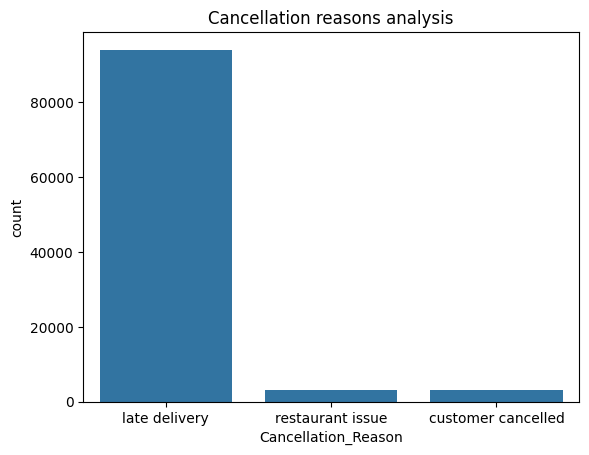

In [ ]:
sns.countplot(x=df['Cancellation_Reason'])
plt.title("Cancellation reasons analysis")
plt.xlabel("Cancellation_Reason")
plt.show()

INSIGHTS:

Late delivery is the major cancellation of the reason

customer cancellation are comparitively low

Restaurant issues have moderate impact

**Correlation analysis among numeric features**


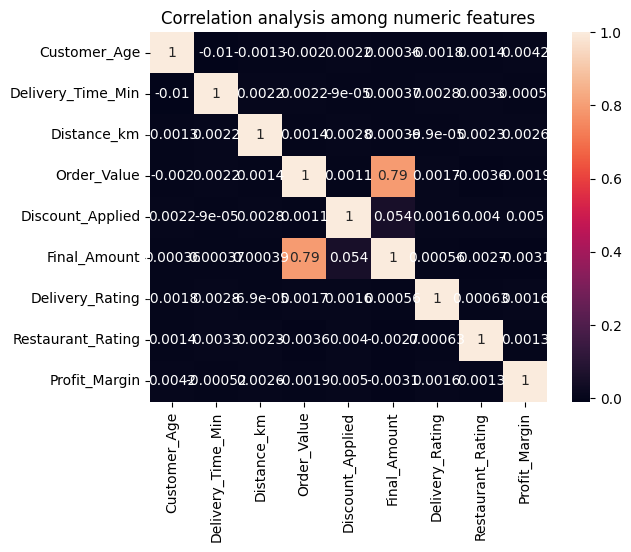

In [ ]:
analysed_df = df.select_dtypes(include='number')
sns.heatmap(analysed_df.corr(), annot=True)
plt.title("Correlation analysis among numeric features")
plt.show()

INSIGHTS:

Strong Positive Correlation between Order Value and Final Amount.

Most Variables Have Very Weak Correlations.

Distance and Delivery Time Show Weak Relationship.

Ratings Are Mostly Independent.

Discount Applied Has Minimal Impact.

The correlation analysis shows that most variables are weakly related, except for Order Value and Final Amount, which have a strong positive correlation.

**Feature Engineering**


**Order day type (Weekday / Weekend)**


In [ ]:
df['order_day_type'] = df['Order_Date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,order_day_type
0,ORD000001,CUST6948,19,male,hyderabad,central,res936,restaurant_29,chinese,2024-10-20,...,upi,delivered,late delivery,DP563,5,4.4,weekend,True,0.13,Weekend
1,ORD000002,CUST6515,39,female,chennai,north,res689,restaurant_419,chinese,2024-08-12,...,cod,delivered,late delivery,DP369,5,4.7,weekday,True,0.48,Weekday
2,ORD000003,CUST1765,39,male,delhi,south,res723,restaurant_244,arabian,2024-12-08,...,wallet,delivered,late delivery,DP580,4,4.9,weekend,True,0.08,Weekend
3,ORD000004,CUST2744,39,male,mumbai,central,res951,restaurant_178,chinese,2024-10-08,...,upi,cancelled,late delivery,DP155,2,3.4,weekday,False,0.04,Weekday
4,ORD000005,CUST4389,57,female,chennai,south,res419,restaurant_262,chinese,2024-02-04,...,card,delivered,late delivery,DP728,2,4.4,weekend,False,0.12,Weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,39,other,mumbai,south,res295,restaurant_500,arabian,2024-06-10,...,card,delivered,late delivery,DP835,2,4.0,weekday,True,0.17,Weekday
99996,ORD099997,CUST6158,39,male,mumbai,east,res157,restaurant_458,arabian,2024-04-22,...,card,delivered,late delivery,DP476,4,3.5,weekday,False,0.15,Weekday
99997,ORD099998,CUST2155,39,other,delhi,east,res287,restaurant_273,indian,2024-02-23,...,cod,cancelled,late delivery,DP577,2,4.0,weekday,True,0.47,Weekday
99998,ORD099999,CUST3015,39,female,delhi,north,res491,restaurant_241,indian,2024-12-10,...,card,delivered,late delivery,DP896,3,4.3,weekday,False,0.44,Weekday


**Peak hour indicator**

In [ ]:
df['Order_Time'] = pd.to_datetime(df['Order_Time'])

# Extract hour
df['hour'] = df['Order_Time'].dt.hour

# Create peak hour indicator
df['peak_hour'] = df['hour'].apply(
    lambda x: True if 18 <= x <= 21 else False
)
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,order_day_type,hour,peak_hour
0,ORD000001,CUST6948,19,male,hyderabad,central,res936,restaurant_29,chinese,2024-10-20,...,late delivery,DP563,5,4.4,weekend,True,0.13,Weekend,0,False
1,ORD000002,CUST6515,39,female,chennai,north,res689,restaurant_419,chinese,2024-08-12,...,late delivery,DP369,5,4.7,weekday,True,0.48,Weekday,0,False
2,ORD000003,CUST1765,39,male,delhi,south,res723,restaurant_244,arabian,2024-12-08,...,late delivery,DP580,4,4.9,weekend,True,0.08,Weekend,0,False
3,ORD000004,CUST2744,39,male,mumbai,central,res951,restaurant_178,chinese,2024-10-08,...,late delivery,DP155,2,3.4,weekday,False,0.04,Weekday,0,False
4,ORD000005,CUST4389,57,female,chennai,south,res419,restaurant_262,chinese,2024-02-04,...,late delivery,DP728,2,4.4,weekend,False,0.12,Weekend,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,39,other,mumbai,south,res295,restaurant_500,arabian,2024-06-10,...,late delivery,DP835,2,4.0,weekday,True,0.17,Weekday,0,False
99996,ORD099997,CUST6158,39,male,mumbai,east,res157,restaurant_458,arabian,2024-04-22,...,late delivery,DP476,4,3.5,weekday,False,0.15,Weekday,0,False
99997,ORD099998,CUST2155,39,other,delhi,east,res287,restaurant_273,indian,2024-02-23,...,late delivery,DP577,2,4.0,weekday,True,0.47,Weekday,0,False
99998,ORD099999,CUST3015,39,female,delhi,north,res491,restaurant_241,indian,2024-12-10,...,late delivery,DP896,3,4.3,weekday,False,0.44,Weekday,0,False


**Profit margin percentage**


In [ ]:
df['Profit_Margin_percentage'] = ((df['Profit_Margin'] - df['Profit_Margin']) / df['Profit_Margin']) * 100
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,order_day_type,hour,peak_hour,Profit_Margin_percentage
0,ORD000001,CUST6948,19,male,hyderabad,central,res936,restaurant_29,chinese,2024-10-20,...,DP563,5,4.4,weekend,True,0.13,Weekend,0,False,0.0
1,ORD000002,CUST6515,39,female,chennai,north,res689,restaurant_419,chinese,2024-08-12,...,DP369,5,4.7,weekday,True,0.48,Weekday,0,False,0.0
2,ORD000003,CUST1765,39,male,delhi,south,res723,restaurant_244,arabian,2024-12-08,...,DP580,4,4.9,weekend,True,0.08,Weekend,0,False,0.0
3,ORD000004,CUST2744,39,male,mumbai,central,res951,restaurant_178,chinese,2024-10-08,...,DP155,2,3.4,weekday,False,0.04,Weekday,0,False,0.0
4,ORD000005,CUST4389,57,female,chennai,south,res419,restaurant_262,chinese,2024-02-04,...,DP728,2,4.4,weekend,False,0.12,Weekend,0,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,39,other,mumbai,south,res295,restaurant_500,arabian,2024-06-10,...,DP835,2,4.0,weekday,True,0.17,Weekday,0,False,0.0
99996,ORD099997,CUST6158,39,male,mumbai,east,res157,restaurant_458,arabian,2024-04-22,...,DP476,4,3.5,weekday,False,0.15,Weekday,0,False,0.0
99997,ORD099998,CUST2155,39,other,delhi,east,res287,restaurant_273,indian,2024-02-23,...,DP577,2,4.0,weekday,True,0.47,Weekday,0,False,0.0
99998,ORD099999,CUST3015,39,female,delhi,north,res491,restaurant_241,indian,2024-12-10,...,DP896,3,4.3,weekday,False,0.44,Weekday,0,False,0.0


**Delivery performance categories**




In [ ]:
def delivery_category(x):
    if x < 30:
        return 'Fast'
    elif x <= 60:
        return 'On-Time'
    else:
        return 'Delayed'

df['Delivery_Performance'] = df['Delivery_Time_Min'].apply(delivery_category)
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,order_day_type,hour,peak_hour,Profit_Margin_percentage,Delivery_Performance
0,ORD000001,CUST6948,19,male,hyderabad,central,res936,restaurant_29,chinese,2024-10-20,...,5,4.4,weekend,True,0.13,Weekend,0,False,0.0,Delayed
1,ORD000002,CUST6515,39,female,chennai,north,res689,restaurant_419,chinese,2024-08-12,...,5,4.7,weekday,True,0.48,Weekday,0,False,0.0,Fast
2,ORD000003,CUST1765,39,male,delhi,south,res723,restaurant_244,arabian,2024-12-08,...,4,4.9,weekend,True,0.08,Weekend,0,False,0.0,Delayed
3,ORD000004,CUST2744,39,male,mumbai,central,res951,restaurant_178,chinese,2024-10-08,...,2,3.4,weekday,False,0.04,Weekday,0,False,0.0,Delayed
4,ORD000005,CUST4389,57,female,chennai,south,res419,restaurant_262,chinese,2024-02-04,...,2,4.4,weekend,False,0.12,Weekend,0,False,0.0,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,39,other,mumbai,south,res295,restaurant_500,arabian,2024-06-10,...,2,4.0,weekday,True,0.17,Weekday,0,False,0.0,Delayed
99996,ORD099997,CUST6158,39,male,mumbai,east,res157,restaurant_458,arabian,2024-04-22,...,4,3.5,weekday,False,0.15,Weekday,0,False,0.0,On-Time
99997,ORD099998,CUST2155,39,other,delhi,east,res287,restaurant_273,indian,2024-02-23,...,2,4.0,weekday,True,0.47,Weekday,0,False,0.0,On-Time
99998,ORD099999,CUST3015,39,female,delhi,north,res491,restaurant_241,indian,2024-12-10,...,3,4.3,weekday,False,0.44,Weekday,0,False,0.0,Delayed


**Customer age groups**

In [ ]:
def age_group(age):
    if age < 18:
        return 'Teen'
    elif age <= 35:
        return 'Young Adult'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Senior'

df['Age_Group'] = df['Customer_Age'].apply(age_group)
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,order_day_type,hour,peak_hour,Profit_Margin_percentage,Delivery_Performance,Age_Group
0,ORD000001,CUST6948,19,male,hyderabad,central,res936,restaurant_29,chinese,2024-10-20,...,4.4,weekend,True,0.13,Weekend,0,False,0.0,Delayed,Young Adult
1,ORD000002,CUST6515,39,female,chennai,north,res689,restaurant_419,chinese,2024-08-12,...,4.7,weekday,True,0.48,Weekday,0,False,0.0,Fast,Adult
2,ORD000003,CUST1765,39,male,delhi,south,res723,restaurant_244,arabian,2024-12-08,...,4.9,weekend,True,0.08,Weekend,0,False,0.0,Delayed,Adult
3,ORD000004,CUST2744,39,male,mumbai,central,res951,restaurant_178,chinese,2024-10-08,...,3.4,weekday,False,0.04,Weekday,0,False,0.0,Delayed,Adult
4,ORD000005,CUST4389,57,female,chennai,south,res419,restaurant_262,chinese,2024-02-04,...,4.4,weekend,False,0.12,Weekend,0,False,0.0,On-Time,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,39,other,mumbai,south,res295,restaurant_500,arabian,2024-06-10,...,4.0,weekday,True,0.17,Weekday,0,False,0.0,Delayed,Adult
99996,ORD099997,CUST6158,39,male,mumbai,east,res157,restaurant_458,arabian,2024-04-22,...,3.5,weekday,False,0.15,Weekday,0,False,0.0,On-Time,Adult
99997,ORD099998,CUST2155,39,other,delhi,east,res287,restaurant_273,indian,2024-02-23,...,4.0,weekday,True,0.47,Weekday,0,False,0.0,On-Time,Adult
99998,ORD099999,CUST3015,39,female,delhi,north,res491,restaurant_241,indian,2024-12-10,...,4.3,weekday,False,0.44,Weekday,0,False,0.0,Delayed,Adult
